In [1]:
# -*- coding: utf-8 -*-
"""
Created on September 17, 2019
Revised on April 01, 2025

@author:       Oscar Trevizo (adapted from Kaggle / S. Stallworth)
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

SVM/SVC with K-Fold Cross Validation and Grid Search
=====================================================

Description:
    Demonstrates binary classification using scikit-learn SVC (Kernel SVM)
    on the Kaggle Social Network Ads dataset. Loads data, selects features
    Age and EstimatedSalary (dropping User ID and Gender), scales with
    StandardScaler, fits an RBF kernel SVM classifier, then extends the
    evaluation with K-Fold cross-validation (cv=10) and GridSearchCV to
    find the best hyperparameters (C, kernel, gamma). Visualizes decision
    boundaries for training and test sets.

    Target variable: Purchased (binary — 0 = did not purchase, 1 = purchased)
    Features used:   Age, EstimatedSalary
    Features dropped: User ID (identifier), Gender (categorical, not encoded)

    Key sklearn API used:
        - StandardScaler.fit_transform() / transform()
        - SVC(kernel="rbf", random_state=0)
        - cross_val_score(cv=10)
        - GridSearchCV(param_grid, scoring="accuracy", cv=10, n_jobs=-1)
        - sklearn.metrics.confusion_matrix()

Data:
    ../data/Social_Network_Ads.csv

References:
    1. Social Network Ads dataset — Kaggle
       https://www.kaggle.com/
    2. S. Stallworth — Classification Models Python
       https://github.com/StephanieStallworth/Classification_Models_Python

Revision History:
    2019-09-17  Original — copied from Kaggle/Stallworth as a learning tool
                - Added comments for deeper understanding

    2025-04-01  Compatibility review and fixes for Python 3.14 / macOS M5
                - Fixed: corrected copy-paste artifact in header (Naive Bayes -> SVM/SVC)
                - Confirmed: no np.NaN usage (clean for NumPy 2.0)
                - Confirmed: SVC, GridSearchCV APIs unchanged
                - Fixed: replaced hardcoded iloc positional indices with
                  explicit column names (Age, EstimatedSalary, Purchased)
                - Fixed: added print() for cross_val_score mean/std
                  (silent variables — only last expression shows in Jupyter)
                - Fixed: added print() for GridSearchCV best_accuracy/best_parameters
                - Fixed: replaced ListedColormap callable pattern with
                  list indexing to avoid TypeError in matplotlib >= 3.7
"""


'\nCreated on September 17, 2019\nRevised on April 01, 2025\n\n@author:       Oscar Trevizo (adapted from Kaggle / S. Stallworth)\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nSVM/SVC with K-Fold Cross Validation and Grid Search\n=====================================================\n\nDescription:\n    Demonstrates binary classification using scikit-learn SVC (Kernel SVM)\n    on the Kaggle Social Network Ads dataset. Loads data, selects features\n    Age and EstimatedSalary (dropping User ID and Gender), scales with\n    StandardScaler, fits an RBF kernel SVM classifier, then extends the\n    evaluation with K-Fold cross-validation (cv=10) and GridSearchCV to\n    find the best hyperparameters (C, kernel, gamma). Visualizes decision\n    boundaries for training and test sets.\n\n    Target variable: Purchased (bi

# Libraries

In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the data

In [3]:
# Importing the dataset
# Columns: User ID, Gender, Age, EstimatedSalary, Purchased
# Features: Age and EstimatedSalary (drop User ID — identifier; Gender — categorical, not encoded)
# Target:   Purchased (binary: 0 = no purchase, 1 = purchase)
dataset = pd.read_csv('../data/Social_Network_Ads.csv')
X = dataset[['Age', 'EstimatedSalary']].values
y = dataset['Purchased'].values


# Split train test datasets

In [4]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Transform to scale the data

In [5]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Fit the model: Support Vector Machine (SVM) / Support Vector Classification (SVC)

In [6]:
# Fitting Kernel SVM to the Training set
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# Predict

In [7]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Evaluate the model

In [8]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[64,  4],
       [ 3, 29]])

# K-Fold Validation

In [9]:
# Applying k-Fold Cross Validation
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
# Print both metrics explicitly — only the last expression shows in Jupyter otherwise
print(f"Accuracy mean: {accuracies.mean():.4f}")
print(f"Accuracy std:  {accuracies.std():.4f}")


Accuracy mean: 0.9033
Accuracy std:  0.0657


# Grid Search: Find the Best Model

In [10]:
# Applying Grid Search to find the best model and the best parameters
from sklearn.model_selection import GridSearchCV
parameters = [{'C': [1, 10, 100, 1000], 'kernel': ['linear']},
              {'C': [1, 10, 100, 1000], 'kernel': ['rbf'], 'gamma': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]}]
grid_search = GridSearchCV(estimator = classifier,
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 10,
                           n_jobs = -1)
grid_search = grid_search.fit(X_train, y_train)
best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_
# Print results explicitly — assigned variables are silent without print()
print(f"Best accuracy:   {best_accuracy:.4f}")
print(f"Best parameters: {best_parameters}")


Best accuracy:   0.9067
Best parameters: {'C': 1, 'gamma': 0.7, 'kernel': 'rbf'}


# Visualize results

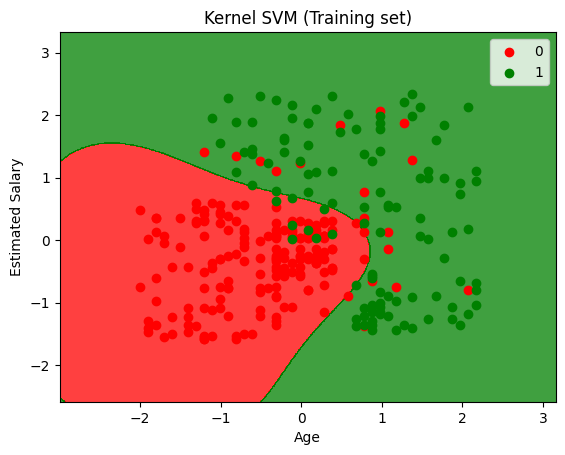

In [11]:
# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ['red', 'green'][i], label = j)
plt.title('Kernel SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

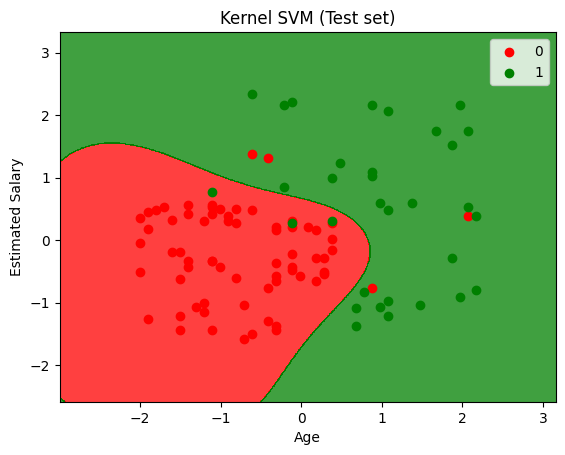

In [12]:
# Visualising the Test set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ['red', 'green'][i], label = j)
plt.title('Kernel SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()